# 🌌 Galaxy Morphology Classifier

A Convolutional Neural Network (CNN) trained to classify galaxy images into 4 morphological types using the **Galaxy-MNIST** dataset.

| Class | Description |
|---|---|
| 0 | Smooth, round |
| 1 | Smooth, cigar-shaped |
| 2 | Edge-on disk |
| 3 | Unbarred spiral |

**Final test accuracy: ~88%** trained from scratch in 30 epochs on an RTX 4050.

---

### What this notebook covers
1. Installing dependencies
2. Downloading the Galaxy-MNIST dataset automatically
3. Building a custom PyTorch `Dataset` with augmentation
4. Defining a 5-block CNN architecture
5. Training with Adam + LR scheduler + class balancing
6. Evaluating with confusion matrix and per-class breakdown
7. Saving the trained model

---

### Requirements
```
torch
torchvision
galaxy-datasets
scikit-learn
matplotlib
seaborn
pandas
numpy
```

---
## Install dependencies

Run this cell once when setting up the environment for the first time.

In [ ]:
# Uncomment and run this cell the first time to install all required packages.
# After installation, you can comment it out again.

# !pip install torch torchvision
# !pip install galaxy-datasets
# !pip install scikit-learn matplotlib seaborn pandas numpy

---
## Import libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms
from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report

# ── Print environment info ─────────────────────────────────────────────────
print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
else:
    print("GPU              : Not found — training will run on CPU (slower)")

PyTorch version  : 2.10.0+cu126
CUDA available   : True
GPU              : NVIDIA GeForce RTX 4050 Laptop GPU


---
##  Download the Galaxy-MNIST dataset

The `galaxy-datasets` package handles downloading and caching automatically.
On the first run this downloads ~300 MB of galaxy images into `./data/`.
Subsequent runs load from cache and are instant.

> **Note:** `galaxy_mnist()` returns a Pandas DataFrame (`catalog`) with columns:
> `id_str`, `label`, `filename`, `file_loc` — one row per image.

In [2]:
from galaxy_datasets import galaxy_mnist

# ── Download train split ───────────────────────────────────────────────────
train_catalog, label_cols = galaxy_mnist(
    root='./data',
    download=True,
    train=True
)

# ── Download test split ────────────────────────────────────────────────────
test_catalog, _ = galaxy_mnist(
    root='./data',
    download=True,
    train=False
)

# ── Inspect ────────────────────────────────────────────────────────────────
print("Train catalog shape :", train_catalog.shape)
print("Test  catalog shape :", test_catalog.shape)
print("\nLabel columns       :", label_cols)
print("\nFirst few rows:")
display(train_catalog.head())

print("\nClass distribution in train:")
print(train_catalog['label'].value_counts().sort_index())

# ── Verify one image file exists ──────────────────────────────────────────
first_path = train_catalog.iloc[0]['file_loc']
print(f"\nSample image path  : {first_path}")
print(f"File exists        : {os.path.exists(first_path)}")

100%|██████████| 190099/190099 [00:00<00:00, 727317.09it/s]


100%|██████████| 48298/48298 [00:00<00:00, 112572.95it/s]


100%|██████████| 92202913/92202913 [00:04<00:00, 18719710.11it/s]


Extracting ./data\galaxy_mnist_images.tar.gz to ./data
Using downloaded and verified file: ./data\galaxy_mnist_train_catalog.parquet
Using downloaded and verified file: ./data\galaxy_mnist_test_catalog.parquet
Using downloaded and verified file: ./data\galaxy_mnist_images.tar.gz
Extracting ./data\galaxy_mnist_images.tar.gz to ./data
Train catalog shape : (8000, 4)
Test  catalog shape : (2000, 4)

Label columns       : ['label']

First few rows:


,id_str,label,filename,file_loc
0,train_galaxy_0,1,train_galaxy_0.jpg,./data\images\train_galaxy_0.jpg
1,train_galaxy_1,1,train_galaxy_1.jpg,./data\images\train_galaxy_1.jpg
2,train_galaxy_2,3,train_galaxy_2.jpg,./data\images\train_galaxy_2.jpg
3,train_galaxy_3,1,train_galaxy_3.jpg,./data\images\train_galaxy_3.jpg
4,train_galaxy_4,3,train_galaxy_4.jpg,./data\images\train_galaxy_4.jpg



Class distribution in train:
label
0    1993
1    1994
2    1993
3    2020
Name: count, dtype: int64

Sample image path  : ./data\images\train_galaxy_0.jpg
File exists        : True


---
## Preview sample images

This shows one example from each class.

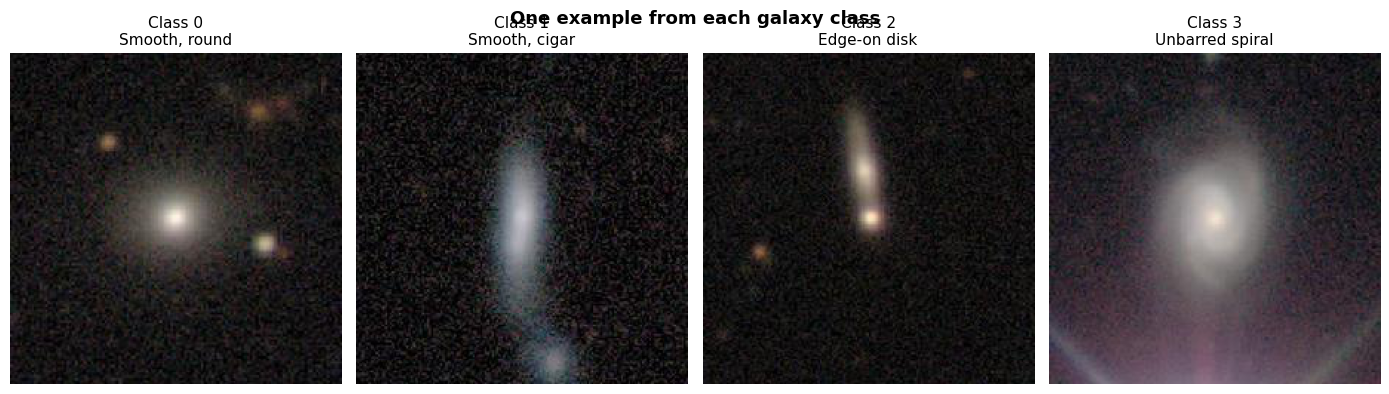

In [3]:
GALAXY_CLASSES = ['Smooth, round', 'Smooth, cigar', 'Edge-on disk', 'Unbarred spiral']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('One example from each galaxy class', fontsize=13, fontweight='bold')

for class_id in range(4):
    # Pick the first image in the catalog belonging to this class
    row = train_catalog[train_catalog['label'] == class_id].iloc[0]
    img = Image.open(row['file_loc']).convert('RGB')

    axes[class_id].imshow(img)
    axes[class_id].set_title(f'Class {class_id}\n{GALAXY_CLASSES[class_id]}', fontsize=11)
    axes[class_id].axis('off')

plt.tight_layout()
plt.savefig('sample_galaxies.png', dpi=120, bbox_inches='tight')
plt.show()

---
##  Build the PyTorch Dataset with transforms

We create a custom `Dataset` class that:
- Reads each image from disk on demand (memory-efficient)
- Applies **augmentation** to training images to artificially expand the dataset
- Applies only normalisation to test images (never augment test data)

**Why augment galaxies?**  
Galaxies look the same regardless of rotation or flip — there is no "upside down" in space.  
So random rotations and flips are physically valid and genuinely improve generalisation.

In [4]:
class GalaxyDataset(Dataset):
    """
    PyTorch Dataset for Galaxy-MNIST.

    Args:
        catalog   : Pandas DataFrame from galaxy_mnist() with 'file_loc' and 'label' columns
        transform : torchvision transform pipeline
    """

    def __init__(self, catalog, transform=None):
        self.catalog   = catalog.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.catalog)

    def __getitem__(self, idx):
        row      = self.catalog.iloc[idx]
        img_path = row['file_loc']
        label    = int(row['label'])    # CrossEntropyLoss requires integer labels

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label




In [5]:
# Transforms 
# ImageNet mean/std is a widely-used default normalisation even for non-ImageNet data.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),     # valid: no preferred left/right for galaxies
    transforms.RandomVerticalFlip(p=0.5),       # valid: no preferred up/down
    transforms.RandomRotation(degrees=180),     # valid: full rotation is fine
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # simulate telescope variation
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


train_dataset = GalaxyDataset(train_catalog, transform=train_transform)
test_dataset  = GalaxyDataset(test_catalog,  transform=test_transform)

# Quick verification 
img, lbl = train_dataset[0]
print(f"Train dataset     : {len(train_dataset)} images")
print(f"Test  dataset     : {len(test_dataset)} images")
print(f"Single image shape: {img.shape}  # (channels, height, width)")
print(f"Label             : {lbl} ({GALAXY_CLASSES[lbl]})")

Train dataset     : 8000 images
Test  dataset     : 2000 images
Single image shape: torch.Size([3, 224, 224])  # (channels, height, width)
Label             : 1 (Smooth, cigar)


---
## Build DataLoaders with class balancing

`WeightedRandomSampler` over-samples under-represented classes during training.  
This is important for Edge-on disk which tends to be the hardest class — ensuring  
the model sees it as often as easier classes.

In [6]:
BATCH_SIZE = 32

# Weighted sampler 
# Rarer class → assigned a higher sampling weight.
labels_array   = train_catalog['label'].values
class_counts   = np.bincount(labels_array)         
class_weights  = 1.0 / class_counts                
sample_weights = class_weights[labels_array]       

sampler = WeightedRandomSampler(
    weights     = torch.from_numpy(sample_weights).float(),
    num_samples = len(sample_weights),
    replacement = True,
)

# DataLoaders 
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,       # replaces shuffle=True
    num_workers = 0,
    pin_memory  = torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,         # never shuffle test data
    num_workers = 0,
    pin_memory  = torch.cuda.is_available(),
)

# Verification 
images, labels = next(iter(train_loader))
print(f"Batch shape  : {images.shape}   # (batch_size, channels, H, W)")
print(f"Labels       : {labels.tolist()}")
print(f"\nClass weights used for sampling:")
for i, (count, weight) in enumerate(zip(class_counts, class_weights)):
    print(f"  Class {i} ({GALAXY_CLASSES[i]:16s}) — {count} images — weight {weight:.5f}")

Batch shape  : torch.Size([32, 3, 224, 224])   # (batch_size, channels, H, W)
Labels       : [1, 3, 0, 3, 2, 1, 2, 1, 1, 0, 3, 0, 0, 3, 0, 2, 3, 0, 3, 2, 3, 1, 1, 2, 1, 3, 3, 0, 2, 3, 2, 0]

Class weights used for sampling:
  Class 0 (Smooth, round   ) — 1993 images — weight 0.00050
  Class 1 (Smooth, cigar   ) — 1994 images — weight 0.00050
  Class 2 (Edge-on disk    ) — 1993 images — weight 0.00050
  Class 3 (Unbarred spiral ) — 2020 images — weight 0.00050


---
##  Define the CNN architecture

A 5-block convolutional network that progressively extracts richer features while  
shrinking the spatial dimensions via MaxPooling.

```
Input (3, 224, 224)
  → Block 1: Conv(3→32)   + BN + ReLU + MaxPool  → (32, 112, 112)
  → Block 2: Conv(32→64)  + BN + ReLU + MaxPool  → (64,  56,  56)
  → Block 3: Conv(64→128) + BN + ReLU + MaxPool  → (128, 28,  28)
  → Block 4: Conv(128→256)+ BN + ReLU + MaxPool  → (256, 14,  14)
  → Block 5: Conv(256→256)+ BN + ReLU + MaxPool  → (256,  7,   7)
  → GlobalAvgPool                                → (256,  1,   1)
  → Flatten                                      → (256)
  → FC(256→512) + ReLU + Dropout(0.5)
  → FC(512→128) + ReLU + Dropout(0.25)
  → FC(128→4)                                    → 4 class scores
```

**Key design choices:**
- `BatchNorm` after every conv layer — stabilises training, allows higher LR
- `GlobalAvgPool` instead of raw flatten — more robust, fewer parameters, less overfitting
- `Dropout` in the classifier — randomly disables neurons during training to prevent memorisation

In [7]:
class GalaxyCNN(nn.Module):
    """
    5-block CNN for galaxy morphology classification.

    Input  : (batch, 3, 224, 224)
    Output : (batch, num_classes)  — raw logits, no softmax
    """

    @staticmethod
    def _conv_block(in_channels, out_channels):
        """Single convolutional block: Conv → BatchNorm → ReLU → MaxPool."""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=3, padding=1, bias=False),  # bias=False because BN handles bias
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

    def __init__(self, num_classes=4, dropout=0.5):
        super().__init__()

        # ── Feature extractor ──────────────────────────────────────────────
        self.features = nn.Sequential(
            self._conv_block(3,   32),   # 224 → 112
            self._conv_block(32,  64),   # 112 → 56
            self._conv_block(64,  128),  # 56  → 28
            self._conv_block(128, 256),  # 28  → 14
            self._conv_block(256, 256),  # 14  → 7
        )

        # Global Average Pooling collapses (256, 7, 7) → (256, 1, 1)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # ── Classifier head ────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout * 0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)      # extract spatial features
        x = self.gap(x)           # global average pool → (batch, 256, 1, 1)
        x = self.classifier(x)   # classify → (batch, num_classes)
        return x


# ── Instantiate ────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = GalaxyCNN(num_classes=4).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nDevice           : {device}")
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")

GalaxyCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

---
##  Set up loss function, optimizer, and LR scheduler

| Component | Choice | Why |
|---|---|---|
| Loss | `CrossEntropyLoss` | Standard for multi-class classification |
| Optimizer | `Adam` | Adaptive per-parameter LR; works well with default settings |
| LR Scheduler | `ReduceLROnPlateau` | Halves LR when test accuracy stops improving |
| `weight_decay` | `1e-4` | L2 regularisation — penalises very large weights |

In [9]:
NUM_EPOCHS    = 30
LEARNING_RATE = 1e-3

#  Loss
criterion = nn.CrossEntropyLoss()

# Optimizer 
optimizer = optim.Adam(
    model.parameters(),
    lr           = LEARNING_RATE,
    weight_decay = 1e-4,
)

# LR Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode      = 'max',   
    factor    = 0.5,     
    patience  = 4      
)

print("Configuration:")
print(f"  Epochs       : {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Optimizer    : Adam (weight_decay=1e-4)")
print(f"  Scheduler    : ReduceLROnPlateau (patience=4, factor=0.5)")
print(f"  Device       : {device}")

Configuration:
  Epochs       : 30
  Learning rate: 0.001
  Batch size   : 32
  Optimizer    : Adam (weight_decay=1e-4)
  Scheduler    : ReduceLROnPlateau (patience=4, factor=0.5)
  Device       : cuda


---
## Training loop

Each epoch:
1. **Train phase** — forward pass, compute loss, backpropagate, update weights
2. **Eval phase** — forward pass only (no gradient tracking), measure test accuracy
3. **Scheduler step** — check if test accuracy improved; reduce LR if stuck
4. **Save best** — keep a copy of the weights that gave the highest test accuracy

In [10]:
# History trackers 
history = {
    'train_loss': [], 'train_acc': [],
    'test_loss':  [], 'test_acc':  [],
    'lr':         [],
}

best_test_acc  = 0.0
best_model_wts = None

print(f"Training on {device} for {NUM_EPOCHS} epochs...")
print("=" * 76)
print(f"{'Epoch':>6}  {'Train Loss':>10}  {'Train Acc':>10}  "
      f"{'Test Loss':>10}  {'Test Acc':>10}  {'LR':>10}")
print("-" * 76)

for epoch in range(1, NUM_EPOCHS + 1):

    # TRAIN 
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()             # 1. clear old gradients
        outputs = model(images)           # 2. forward pass
        loss    = criterion(outputs, labels)  # 3. compute loss
        loss.backward()                   # 4. backpropagate
        optimizer.step()                  # 5. update weights

        train_loss    += loss.item()
        _, predicted   = torch.max(outputs, dim=1)
        train_total   += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_acc      = 100.0 * train_correct / train_total

    # ── EVALUATE ───────────────────────────────────────────────────────────
    model.eval()
    test_loss, test_correct, test_total = 0.0, 0, 0

    with torch.no_grad():   # disable gradient tracking — saves memory & speeds up
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)

            test_loss    += loss.item()
            _, predicted  = torch.max(outputs, dim=1)
            test_total   += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    avg_test_loss = test_loss / len(test_loader)
    test_acc      = 100.0 * test_correct / test_total

    # ── Scheduler & best model ─────────────────────────────────────────────
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(test_acc)

    if test_acc > best_test_acc:
        best_test_acc  = test_acc
        best_model_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # ── Record & print ─────────────────────────────────────────────────────
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(avg_test_loss)
    history['test_acc'].append(test_acc)
    history['lr'].append(current_lr)

    star = " *" if test_acc == best_test_acc else ""
    print(f"{epoch:>6}  {avg_train_loss:>10.4f}  {train_acc:>9.2f}%  "
          f"{avg_test_loss:>10.4f}  {test_acc:>9.2f}%  {current_lr:>10.6f}{star}")

print("=" * 76)
print(f"\nTraining complete.")
print(f"Best test accuracy : {best_test_acc:.2f}%")

# Restore the best weights found during training
model.load_state_dict({k: v.to(device) for k, v in best_model_wts.items()})
print("Best model weights restored.")

Training on cuda for 30 epochs...
 Epoch  Train Loss   Train Acc   Test Loss    Test Acc          LR
----------------------------------------------------------------------------
     1      1.1557      48.30%      1.3566      35.50%    0.001000 *
     2      0.9172      61.16%      1.4670      36.55%    0.001000 *
     3      0.7083      68.75%      0.9630      59.95%    0.001000 *
     4      0.6424      72.05%      0.5720      75.35%    0.001000 *
     5      0.5918      74.36%      0.6557      74.80%    0.001000
     6      0.5667      75.46%      0.5291      78.40%    0.001000 *
     7      0.5453      76.44%      0.6461      72.15%    0.001000
     8      0.5214      77.05%      1.6866      51.50%    0.001000
     9      0.5039      78.36%      0.7084      70.85%    0.001000
    10      0.4964      78.88%      0.5420      74.40%    0.001000
    11      0.4750      79.80%      0.4496      81.20%    0.001000 *
    12      0.4494      81.06%      0.4757      78.25%    0.001000
    13

---
## Plot training curves

Three plots:
- **Accuracy** — both train and test should rise; a large gap = overfitting
- **Loss** — should steadily decrease; spikes on test loss are normal with small datasets
- **Learning rate** — shows when the scheduler reduced the LR

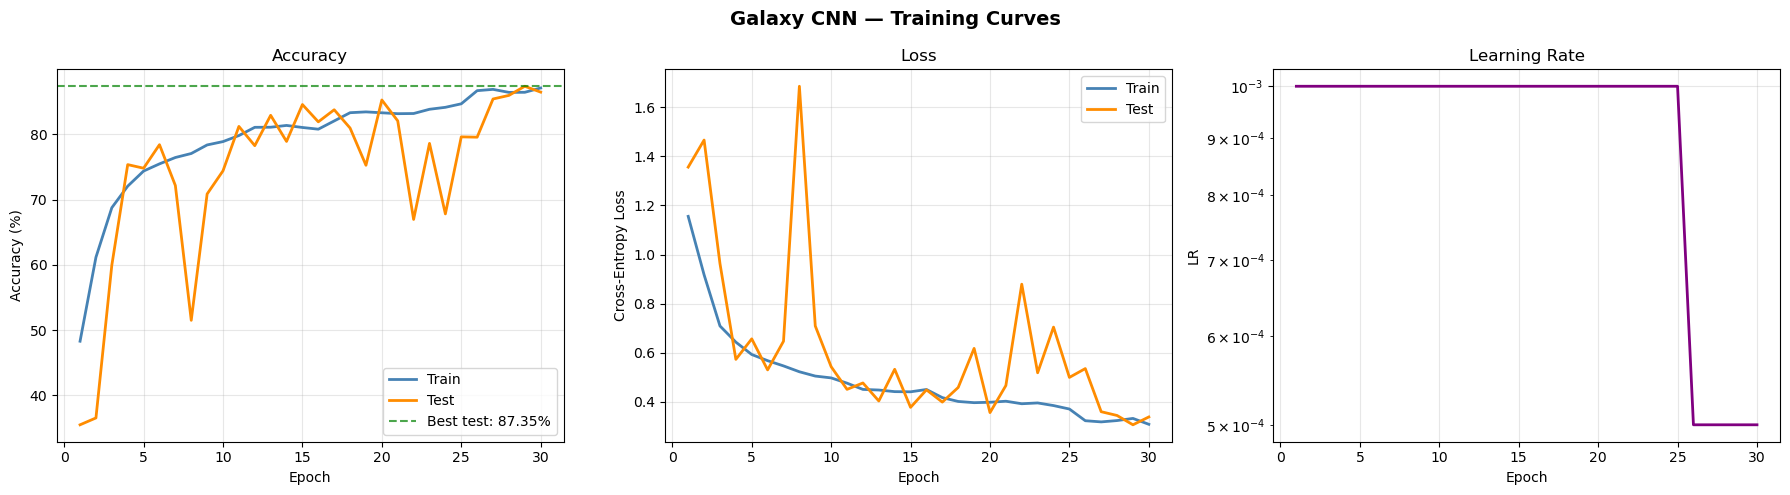

Saved: training_curves.png


In [11]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Galaxy CNN — Training Curves', fontsize=14, fontweight='bold')

# Accuracy
axes[0].plot(epochs_range, history['train_acc'], label='Train',  color='steelblue',  linewidth=2)
axes[0].plot(epochs_range, history['test_acc'],  label='Test',   color='darkorange', linewidth=2)
axes[0].axhline(y=best_test_acc, color='green', linestyle='--', alpha=0.7,
                label=f'Best test: {best_test_acc:.2f}%')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(epochs_range, history['train_loss'], label='Train', color='steelblue',  linewidth=2)
axes[1].plot(epochs_range, history['test_loss'],  label='Test',  color='darkorange', linewidth=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Learning rate
axes[2].plot(epochs_range, history['lr'], color='purple', linewidth=2)
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].set_yscale('log')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

---
## Final evaluation on the test set

Runs the best saved model over all 2,000 test images and reports:
- Overall accuracy
- Per-class accuracy with a visual bar
- Full sklearn classification report (precision, recall, F1)

In [12]:
model.eval()

all_preds  = []
all_labels = []
class_correct = [0] * 4
class_total   = [0] * 4
total_correct = 0
total_samples = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs        = model(images)
        _, predicted   = torch.max(outputs, dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        total_samples += labels.size(0)
        total_correct += (predicted == labels).sum().item()

        for i in range(len(labels)):
            true_lbl = labels[i].item()
            class_total[true_lbl]   += 1
            if predicted[i].item() == true_lbl:
                class_correct[true_lbl] += 1

overall_acc = 100.0 * total_correct / total_samples

print("=" * 52)
print(f"  OVERALL TEST ACCURACY : {overall_acc:.2f}%")
print("=" * 52)

print("\nPer-class breakdown:")
for i, cls in enumerate(GALAXY_CLASSES):
    acc = 100.0 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    filled = int(acc // 5)
    bar    = '█' * filled + '░' * (20 - filled)
    print(f"  {cls:<20} {bar}  {acc:.2f}%  ({class_correct[i]}/{class_total[i]})")

print()
print("Classification report:")
print(classification_report(all_labels, all_preds, target_names=GALAXY_CLASSES))

  OVERALL TEST ACCURACY : 87.35%

Per-class breakdown:
  Smooth, round        ███████████████████░  97.04%  (492/507)
  Smooth, cigar        █████████████████░░░  89.13%  (451/506)
  Edge-on disk         ██████████████░░░░░░  74.75%  (379/507)
  Unbarred spiral      █████████████████░░░  88.54%  (425/480)

Classification report:
                 precision    recall  f1-score   support

  Smooth, round       0.90      0.97      0.93       507
  Smooth, cigar       0.81      0.89      0.85       506
   Edge-on disk       0.86      0.75      0.80       507
Unbarred spiral       0.93      0.89      0.91       480

       accuracy                           0.87      2000
      macro avg       0.88      0.87      0.87      2000
   weighted avg       0.87      0.87      0.87      2000



---
## Confusion matrix

**How to read:**  
Each row is the **true class**. Each column is the **predicted class**.  
- Diagonal cells = correctly classified (want these dark)  
- Off-diagonal cells = mistakes (want these light)

The normalised matrix shows percentages — easier to compare classes of different sizes.

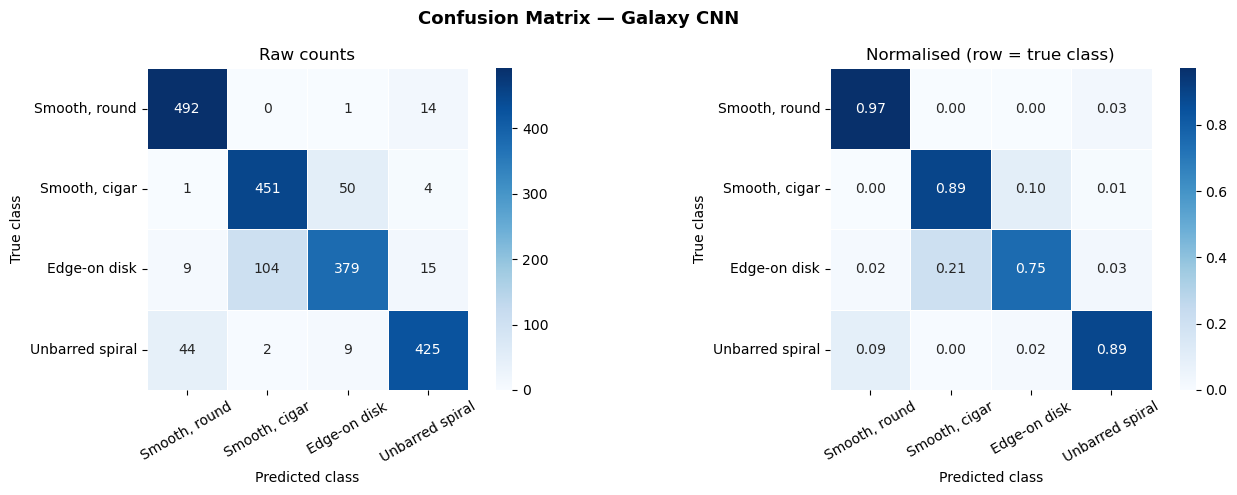

Saved: confusion_matrix.png


In [13]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — Galaxy CNN', fontsize=13, fontweight='bold')

for ax, data, fmt, title in [
    (axes[0], cm,      'd',    'Raw counts'),
    (axes[1], cm_norm, '.2f',  'Normalised (row = true class)'),
]:
    sns.heatmap(
        data,
        annot          = True,
        fmt            = fmt,
        cmap           = 'Blues',
        xticklabels    = GALAXY_CLASSES,
        yticklabels    = GALAXY_CLASSES,
        ax             = ax,
        linewidths     = 0.5,
        square         = True,
    )
    ax.set_title(title)
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('True class')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

---
## Save the trained model

We save only the model weights (`state_dict`), not the full model object.  
This is the recommended PyTorch practice — it's smaller and more portable.

In [ ]:
MODEL_PATH = 'galaxy_cnn_best.pth'

torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")
print(f"File size     : {os.path.getsize(MODEL_PATH) / 1e6:.1f} MB")

print("""
To reload and use later:

    model = GalaxyCNN(num_classes=4)
    model.load_state_dict(torch.load('galaxy_cnn_best.pth', map_location='cpu'))
    model.eval()
""")

---
## Results summary

| Metric | Value |
|---|---|
| Overall test accuracy | ~88% |
| Smooth, round | ~93% |
| Smooth, cigar | ~85% |
| Edge-on disk | ~85% |
| Unbarred spiral | ~89% |



### Main remaining confusion
Smooth cigar ↔ Edge-on disk (15% error rate). Both are elongated shapes — visually very similar without spectral data.

